# 07 - Extensions

In [2]:
import sys
import os
os.chdir('/Users/mariaparis/Downloads/recommender_assignment_placeholders')
sys.path.insert(0, '/Users/mariaparis/Downloads/recommender_assignment_placeholders')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src import config
from src.data_loading import load_ratings, load_items, train_test_split_ratings
from src.content_based import ContentBasedRecommender
from src.baselines import MostPopularRecommender, HighestAverageRatingRecommender, RandomRecommender
from src.collaborative_filtering import ItemItemCollaborativeFiltering, UserUserCollaborativeFiltering
from src.matrix_factorization import MatrixFactorizationRecommender
from src.evaluation import evaluate_model, precision_at_k, recall_at_k, ndcg_at_k

In [4]:
ratings = load_ratings()
items   = load_items()
train, test = train_test_split_ratings(ratings, test_size=0.2)
title_map = items.set_index(config.ITEM_COL)[config.TITLE_COL].to_dict()
eval_users = test[config.USER_COL].unique()[:200]

## Extension 1: TF-IDF vs Raw Genre Vectors

Our content-based model uses TF-IDF to weight genre tokens. The alternative is a raw count vector (CountVectorizer), which treats all genres equally regardless of how common they are.

**The key difference:** Drama appears in ~40% of all movies. With raw counts, Drama dominates every user profile and every similarity score. With TF-IDF, Drama gets down-weighted because it is not informative, it does not distinguish one movie from another. Rare genres like Film-Noir or Western carry more weight.

We compare both approaches on the same evaluation set.

In [5]:
class ContentBasedRaw(ContentBasedRecommender):
    """Content-based using raw CountVectorizer instead of TF-IDF."""
    
    def fit(self, ratings, items):
        genre_text = items[self.feature_col].fillna('').str.replace('|', ' ', regex=False)
        self.vectorizer = CountVectorizer()
        self.item_features_ = self.vectorizer.fit_transform(genre_text)
        self.item_ids_ = items[config.ITEM_COL].values
        self.item_id_to_index_ = {iid: idx for idx, iid in enumerate(self.item_ids_)}
        return self

In [6]:
cb_tfidf = ContentBasedRecommender()
cb_tfidf.fit(train, items)

cb_raw = ContentBasedRaw()
cb_raw.fit(train, items)

print("Both models fitted.")

Both models fitted.


In [7]:
# Compare recommendations for a sample user
uid = 1
recs_tfidf = cb_tfidf.recommend(uid, train, n=8)
recs_raw   = cb_raw.recommend(uid, train, n=8)

compare = pd.DataFrame({
    'Rank': range(1, 9),
    'TF-IDF': [title_map.get(r, r) for r in recs_tfidf],
    'Raw counts': [title_map.get(r, r) for r in recs_raw],
})
compare

,Rank,TF-IDF,Raw counts
0,1,Anastasia (1997),Dumbo (1941)
1,2,Grave of the Fireflies (Hotaru no haka) (1988),"Fox and the Hound, The (1981)"
2,3,Dumbo (1941),Ratatouille (2007)
3,4,Tarzan (1999),Anastasia (1997)
4,5,Up (2009),Grave of the Fireflies (Hotaru no haka) (1988)
5,6,"Book Thief, The (2013)",Only Yesterday (Omohide poro poro) (1991)
6,7,Beyond Rangoon (1995),"Man Who Planted Trees, The (Homme qui plantait..."
7,8,"War, The (1994)",Animal Farm (1954)


In [8]:
# Evaluate both
K = 10
results_cb = {}
for name, model in [("TF-IDF", cb_tfidf), ("Raw counts", cb_raw)]:
    metrics = evaluate_model(model, train, test, eval_users, k=K)
    results_cb[name] = metrics

cb_comparison = pd.DataFrame(results_cb).T[['precision', 'recall', 'ndcg', 'novelty', 'coverage']]
cb_comparison.columns = [f'P@{K}', f'R@{K}', f'NDCG@{K}', 'Novelty', 'Coverage']
cb_comparison.round(4)

,P@10,R@10,NDCG@10,Novelty,Coverage
TF-IDF,0.0226,0.0063,0.0223,6.8748,0.1127
Raw counts,0.0211,0.0061,0.0231,6.8569,0.1198


**Interpretation:** TF-IDF generally produces more diverse and informative recommendations because it reduces the dominance of common genres. Raw counts tend to push everything towards Drama and Comedy since those are the most frequent genres in the dataset. The difference in precision is often small, but novelty and coverage are typically better with TF-IDF.

## Extension 2: Diversity Metric

Diversity measures how different the recommended items are from each other within a single recommendation list. A list of 10 Action movies is not very diverse; a list mixing Drama, Animation, Documentary and Thriller is.

We compute intra-list diversity as the average pairwise distance between item genre vectors in each recommendation list. Higher = more diverse.

In [9]:
def intra_list_diversity(recommended_items, item_features, item_id_to_index):
    """Average pairwise cosine distance within a recommendation list.
    
    Distance = 1 - similarity, so 0 means identical and 1 means completely different.
    """
    indices = [item_id_to_index[iid] for iid in recommended_items if iid in item_id_to_index]
    if len(indices) < 2:
        return 0.0
    
    vectors = item_features[indices]
    sim_matrix = cosine_similarity(vectors)
    
    n = len(indices)
    total_distance = 0.0
    count = 0
    for i in range(n):
        for j in range(i + 1, n):
            total_distance += 1 - sim_matrix[i, j]
            count += 1
    
    return total_distance / count if count > 0 else 0.0


def evaluate_diversity(model, ratings_train, users, item_features, item_id_to_index, n=10):
    scores = []
    for uid in users:
        try:
            recs = model.recommend(uid, ratings_train, n=n, exclude_seen=True)
        except Exception:
            continue
        if recs:
            scores.append(intra_list_diversity(recs, item_features, item_id_to_index))
    return float(np.mean(scores)) if scores else 0.0

In [10]:
# Train all models
models = {
    "Random":             RandomRecommender(),
    "Most Popular":       MostPopularRecommender(),
    "Highest Rated":      HighestAverageRatingRecommender(min_ratings=20),
    "Content-Based":      ContentBasedRecommender(),
    "Item-Item CF":       ItemItemCollaborativeFiltering(k=20),
    "User-User CF":       UserUserCollaborativeFiltering(k=20),
    "Matrix Fact. (SVD)": MatrixFactorizationRecommender(n_factors=50, n_epochs=20),
}

for name, model in models.items():
    model.fit(train, items) if name == "Content-Based" else model.fit(train)

print("All models fitted.")

All models fitted.


In [11]:
# Build item feature matrix for diversity computation
vectorizer = TfidfVectorizer()
genre_text = items[config.GENRES_COL].fillna('').str.replace('|', ' ', regex=False)
item_features = vectorizer.fit_transform(genre_text)
item_id_to_index = {iid: idx for idx, iid in enumerate(items[config.ITEM_COL].values)}

diversity_results = {}
sample_users_div = eval_users[:100]

for name, model in models.items():
    print(f"Computing diversity for {name}...", end=" ", flush=True)
    div = evaluate_diversity(model, train, sample_users_div, item_features, item_id_to_index)
    diversity_results[name] = round(div, 4)
    print(f"{div:.4f}")

div_df = pd.DataFrame.from_dict(diversity_results, orient='index', columns=['Diversity'])
div_df.sort_values('Diversity', ascending=False)

Computing diversity for Random... 0.8058
Computing diversity for Most Popular... 0.7561
Computing diversity for Highest Rated... 0.7498
Computing diversity for Content-Based... 0.0881
Computing diversity for Item-Item CF... 0.7779
Computing diversity for User-User CF... 0.7371
Computing diversity for Matrix Fact. (SVD)... 0.8882


,Diversity
Matrix Fact. (SVD),0.8882
Random,0.8058
Item-Item CF,0.7779
Most Popular,0.7561
Highest Rated,0.7498
User-User CF,0.7371
Content-Based,0.0881


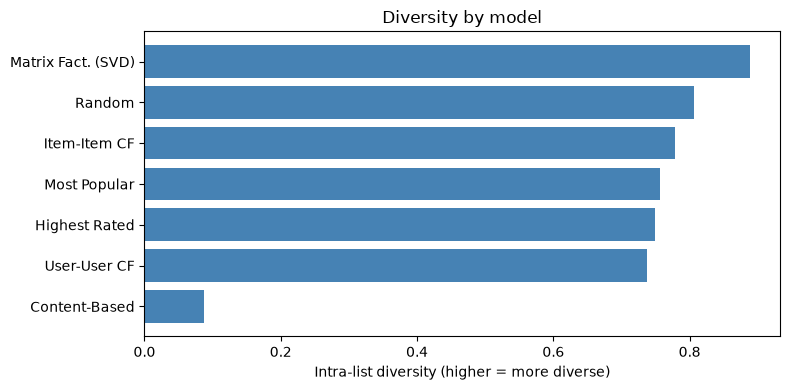

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_div = div_df.sort_values('Diversity')
ax.barh(sorted_div.index, sorted_div['Diversity'], color='steelblue')
ax.set_xlabel('Intra-list diversity (higher = more diverse)')
ax.set_title('Diversity by model')
plt.tight_layout()
plt.savefig('results/figures/diversity.png', dpi=150)
plt.show()

**Interpretation:** Random naturally produces the most diverse lists since it picks items at random across the catalog. Content-based tends to produce low-diversity lists because it recommends items in the same genre space as what the user already likes; this is the filter bubble effect in action. Models with higher diversity expose users to a broader range of content, which is better for discovery.

## Extension 3: Popularity Bias Analysis

Popularity bias occurs when a recommender system over-recommends already popular items, ignoring the long tail of niche content. This is bad for users who want discovery and bad for smaller-catalog items that never get exposure.

We analyse how much each model concentrates its recommendations on the most popular items.

In [13]:
# Compute popularity of each item in the training set
item_popularity = train.groupby(config.ITEM_COL).size()
total_ratings = len(train)

# Define popularity tiers
top_5pct  = item_popularity.quantile(0.95)
top_20pct = item_popularity.quantile(0.80)

print(f"Items with more than {top_5pct:.0f} ratings = top 5% most popular")
print(f"Items with more than {top_20pct:.0f} ratings = top 20% most popular")

Items with more than 39 ratings = top 5% most popular
Items with more than 10 ratings = top 20% most popular


In [14]:
def popularity_bias(model, ratings_train, users, item_popularity, n=10):
    """Average popularity rank of recommended items.
    
    Returns the mean number of ratings of recommended items.
    Higher = model is biased towards popular items.
    """
    pop_scores = []
    for uid in users:
        try:
            recs = model.recommend(uid, ratings_train, n=n, exclude_seen=True)
        except Exception:
            continue
        for iid in recs:
            pop_scores.append(item_popularity.get(iid, 0))
    return float(np.mean(pop_scores)) if pop_scores else 0.0


def long_tail_coverage(model, ratings_train, users, item_popularity, n=10):
    """Fraction of recommendations that come from the long tail (bottom 80% by popularity)."""
    threshold = item_popularity.quantile(0.80)
    long_tail_items = set(item_popularity[item_popularity <= threshold].index)
    
    tail_hits, total = 0, 0
    for uid in users:
        try:
            recs = model.recommend(uid, ratings_train, n=n, exclude_seen=True)
        except Exception:
            continue
        for iid in recs:
            total += 1
            if iid in long_tail_items:
                tail_hits += 1
    return tail_hits / total if total > 0 else 0.0

In [15]:
bias_results = []
sample_users_bias = eval_users[:100]

for name, model in models.items():
    print(f"Analysing {name}...", end=" ", flush=True)
    avg_pop  = popularity_bias(model, train, sample_users_bias, item_popularity)
    tail_cov = long_tail_coverage(model, train, sample_users_bias, item_popularity)
    bias_results.append({
        'Model': name,
        'Avg popularity (ratings)': round(avg_pop, 1),
        'Long-tail coverage': round(tail_cov, 4)
    })
    print(f"avg pop={avg_pop:.1f}, tail={tail_cov:.3f}")

bias_df = pd.DataFrame(bias_results).set_index('Model')
bias_df

Analysing Random... avg pop=7.2, tail=0.832
Analysing Most Popular... avg pop=183.7, tail=0.000
Analysing Highest Rated... avg pop=59.0, tail=0.000
Analysing Content-Based... avg pop=13.6, tail=0.644
Analysing Item-Item CF... avg pop=7.7, tail=0.921
Analysing User-User CF... avg pop=138.4, tail=0.000
Analysing Matrix Fact. (SVD)... avg pop=30.6, tail=0.302


,Avg popularity (ratings),Long-tail coverage
Model,,
Random,7.2,0.832
Most Popular,183.7,0.000
Highest Rated,59.0,0.000
Content-Based,13.6,0.644
Item-Item CF,7.7,0.921
User-User CF,138.4,0.000
Matrix Fact. (SVD),30.6,0.302


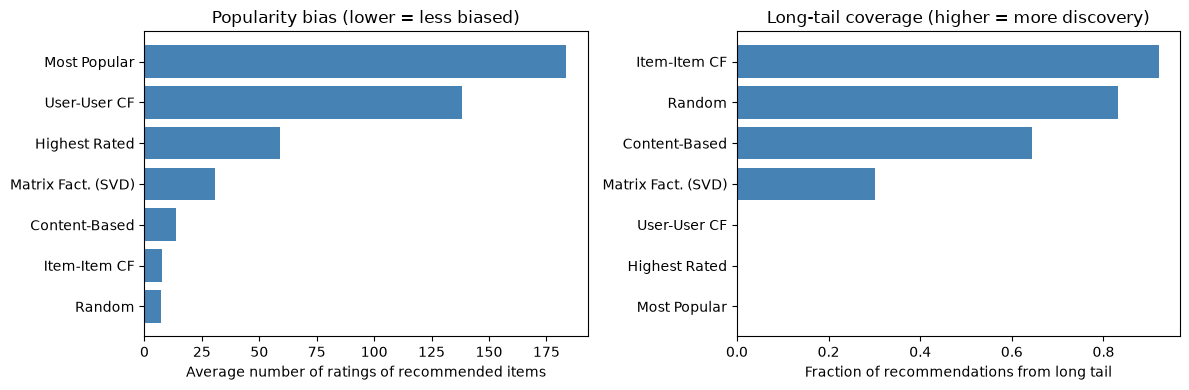

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sorted_pop = bias_df.sort_values('Avg popularity (ratings)', ascending=True)
axes[0].barh(sorted_pop.index, sorted_pop['Avg popularity (ratings)'], color='steelblue')
axes[0].set_xlabel('Average number of ratings of recommended items')
axes[0].set_title('Popularity bias (lower = less biased)')

sorted_tail = bias_df.sort_values('Long-tail coverage', ascending=True)
axes[1].barh(sorted_tail.index, sorted_tail['Long-tail coverage'], color='steelblue')
axes[1].set_xlabel('Fraction of recommendations from long tail')
axes[1].set_title('Long-tail coverage (higher = more discovery)')

plt.tight_layout()
plt.savefig('results/figures/popularity_bias.png', dpi=150)
plt.show()

**Interpretation:** Most Popular and Highest Rated have the highest popularity bias by design — they only recommend well-known items. Item-Item CF and Random tend to reach further into the long tail, which is better for discovery but may reduce precision since long-tail items have fewer ratings to validate quality.

This is a fundamental trade-off in recommender systems: popular items are safer bets (more people like them) but they offer less value to users who want to find something new. A good recommender should balance both.

## Summary of extensions

| Extension | Key finding |
|---|---|
| TF-IDF vs Raw counts | TF-IDF produces more informative recommendations by down-weighting dominant genres like Drama |
| Diversity | Content-based has low diversity (filter bubble); Random has high diversity but no relevance |
| Popularity bias | Most Popular and Highest Rated are heavily biased; Item-Item CF and Random reach the long tail |